# Spectral Methods and Matrix Decompositions for AI

## Recommended Readings & YouTube Channels

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
Here are some excellent resources for learning about applied mathematics, machine learning, and related topics:

- **Steve Brunton** – Researcher in dynamical systems and machine learning.  
  [YouTube Channel](https://www.youtube.com/@Eigensteve)

- **Welch Labs** – Educational videos on mathematics and physics concepts.  
  [YouTube Channel](https://www.youtube.com/@WelchLabsVideo)

- **Josef Teichmann's Teaching Materials** – Lectures and course materials on stochastic analysis and applied mathematics.  
  [ETH Zürich Page](https://people.math.ethz.ch/~jteichma/index.php?content=teach)
    
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p>
        <div style="text-align: center;">
<img src="./muskmessage.jpeg" width="200" height="300">
</div>
  </p>
  </div>
</div>

## Block 1 (45 min) — Theory  

### Spectral Calculus and Singular Value Decomposition (SVD)

---

### Motivation

**Why spectral methods?**

- High-dimensional data often exhibits strong correlations  
- Many datasets admit accurate **low-rank approximations**  
- Spectral methods enable **noise reduction** and **numerical stability**

The spectrum reveals the intrinsic geometry of data and the behavior of algorithms acting on it.

---

### 1. Spectral Theorem for Symmetric Matrices

**Theorem.**  
Let $A \in \mathbb{R}^{n \times n}$ be a symmetric matrix. Then:
- All eigenvalues of $A$ are real.
- Eigenvectors corresponding to distinct eigenvalues are orthogonal.
- There exists an orthonormal basis of eigenvectors such that
$$
A = Q \Lambda Q^\top,
$$
where
- $Q$ is an orthogonal matrix whose columns are the normalized eigenvectors of $A$,
- $\Lambda = \mathrm{diag}(\lambda_1, \dots, \lambda_n)$, with $\lambda_i \in \mathbb{R}$.

**Corollary (Quadratic Forms).**  
The quadratic form induced by a symmetric matrix admits the decomposition
$$
x^\top A x = \sum_{i=1}^n \lambda_i (q_i^\top x)^2.
$$
Thus, each eigenvalue controls the curvature of the quadratic form along its corresponding eigen-direction.


#### Spectral Calculus

The diagonalization of $A$ allows us to define functions of matrices in a natural way.  
Given a function $f : \mathbb{R} \to \mathbb{R}$, define
$$
f(A) = Q f(\Lambda) Q^\top,
$$
where $f(\Lambda) = \mathrm{diag}(f(\lambda_1), \dots, f(\lambda_n))$.

This construction defines a functional calculus for symmetric matrices: functions act independently on each eigenmode.


#### Examples

- **Matrix exponential.**  
  The matrix exponential $X(t) = e^{tA}$ gives the general solution of the linear ODE
  $$
  \dot{X}(t) = A X(t).
  $$

- **Matrix square root.**  
  If all eigenvalues of $A$ are nonnegative (i.e., $A$ is positive semidefinite), then the square root
  $$
  A^{1/2} = Q \Lambda^{1/2} Q^\top
  $$
  is well-defined.


#### Relevance to Machine Learning

- **Kernel methods.**  
  Kernel matrices are symmetric positive semidefinite by construction.  
  Their eigenvalues and eigenvectors determine the effective dimensionality of the feature space and control model capacity.  
  Spectral decay explains why kernel PCA, kernel ridge regression, and Gaussian processes can generalize well despite operating in very high (or infinite) dimensional spaces.

- **Graph Laplacians.**  
  The (normalized) graph Laplacian is a symmetric positive semidefinite operator encoding local neighborhood structure.  
  Its spectrum governs diffusion, smoothing, and connectivity properties on graphs.  
  Eigenvectors of the Laplacian provide meaningful low-dimensional embeddings of data, forming the basis of manifold learning and graph-based semi-supervised learning.

- **Spectral clustering.**  
  Spectral clustering relaxes a combinatorial partitioning problem into a continuous one by using eigenvectors of the graph Laplacian.  
  Clusters correspond to approximately invariant subspaces associated with small eigenvalues.  
  This explains both the robustness of the method and its ability to detect non-convex cluster structures.


Spectral calculus explains how learning algorithms amplify, suppress, or regularize different directions in data space.

### Singular Value Decomposition (SVD)

**Theorem (Existence of the SVD):**
For any matrix $A \in \mathbb{R}^{m \times n}$, there exist orthogonal matrices
$U \in \mathbb{R}^{m \times m}$, $V \in \mathbb{R}^{n \times n},$
and a diagonal matrix $\Sigma = \mathrm{diag}(\sigma_1,\dots,\sigma_r) \in \mathbb{R}^{m \times n}$, 
$\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$,
such that
$$
A = U \Sigma V^\top.
$$
The numbers $\sigma_i$ are the **singular values** of $A$, and $r = \mathrm{rank}(A)$.


*Proof (via the Spectral Theorem)*

1. Consider the symmetric matrix $A^\top A \in \mathbb{R}^{n \times n}$.  
   It is positive semidefinite:
   $$
   x^\top A^\top A x = \|Ax\|^2 \ge 0,\quad x\in\mathbb{R}^n.
   $$

3. By the **spectral theorem**, there exists an orthogonal matrix $V$ and a diagonal matrix
   $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_n), \quad \lambda_i \ge 0$,
   such that
   $$
   A^\top A = V \Lambda V^\top.
   $$

4. Define the singular values by $\sigma_i = \sqrt{\lambda_i}$, and let
   $\Sigma = \mathrm{diag}(\sigma_1,\dots,\sigma_n)$.

5. For each $i$ with $\sigma_i > 0$, define
   $$
   u_i := \frac{1}{\sigma_i} A v_i.
   $$
   Then $\|u_i\|=1$, and the vectors $\{u_i\}$ are orthonormal.

6. Complete $\{u_i\}$ to an orthonormal basis of $\mathbb{R}^m$, forming an orthogonal matrix $U$.

7. With these choices,
   $$
   A = U \Sigma V^\top.
   $$

Q.E.D.

#### Relation to the Spectral Theorem

The SVD simultaneously diagonalizes the two symmetric matrices
$$
A^\top A = V \Sigma^2 V^\top, \qquad
AA^\top = U \Sigma^2 U^\top.
$$
Thus:
- right singular vectors = eigenvectors of $A^\top A$,
- left singular vectors = eigenvectors of $AA^\top$,
- singular values = square roots of the nonzero eigenvalues.

SVD is therefore can be considered as a **spectral theorem for arbitrary (rectangular) matrices**.

#### Geometric Interpretation, non-uniqueness
The action of an arbitrary matrix $A$ can be decomposed into three simple geometric transformations:
$$
x \xrightarrow{V^\top} \text{rotation} \xrightarrow{\Sigma} \text{scaling} \xrightarrow{U} \text{rotation}
$$

Thus, any linear map sends the unit sphere to an ellipsoid whose principal directions are given by the singular vectors, and whose semi-axis lengths are the singular values.

The SVD is **not unique**:

- If a singular value has multiplicity $>1$, the corresponding singular vectors are only determined up to an orthogonal rotation of that subspace.
- Even for simple singular values, the signs of corresponding columns of $U$ and $V$ can be flipped simultaneously.

What *is* unique: the singular values themselves (up to ordering).


#### Autoencoders and the SVD

An **autoencoder** is a neural network trained to reconstruct its input:
$$
x \xrightarrow{\text{encoder}} z \xrightarrow{\text{decoder}} \hat x,
\quad \hat x \approx x.
$$

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
**Uses:**
- dimensionality reduction,
- feature learning,
- denoising,
- representation learning.

**Connection to SVD:**
SVD can be considered as a **linear autoencoder** with:
- linear encoder and decoder,
- mean squared reconstruction error,
- no regularization,
- latent dimension $k$.

**Interpretation:**
- SVD: optimal rank-\(k\) approximation of a linear operator,
- Linear autoencoder: optimal rank-\(k\) information bottleneck.
    
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p>
        <div style="text-align: center;">
<img src="./SVDencoder_inv.jpeg" width="400" height="400">
</div>
  </p>
  </div>
</div>

Nonlinear autoencoders generalize this idea beyond linear subspaces, but lose the closed-form, spectral interpretation.


**Takeaway:**  
> *The SVD is the mathematical prototype of representation learning; autoencoders are its nonlinear descendants.*

### Applications of SVD

#### 1. The Moore–Penrose Pseudoinverse

**Definition:** Let **$A \in \mathbb{R}^{m \times n}$** have the singular value decomposition
$A = U \Sigma V^\top$. The **Moore–Penrose pseudoinverse** of $A$ is defined as
$$
A^+ = V \Sigma^+ U^\top,
$$
where
$$
\Sigma^+_{ii} =
\begin{cases}
1 / \sigma_i, & \text{if } \sigma_i > 0, \\
0, & \text{otherwise}.
\end{cases}
$$


The pseudoinverse **always exists** for any matrix $A$, regardless of shape or rank.  
Its existence follows directly from the existence of the SVD.

The construction is explicit:
- decompose $A$ via SVD,
- invert the nonzero singular values,
- leave zero singular values unchanged.

The pseudoinverse \( A^+ \) is the **unique** matrix satisfying the four Moore–Penrose equations:
$$
\begin{aligned}
\text{(i)}\;& A A^+ A = A, \\
\text{(ii)}\;& A^+ A A^+ = A^+, \\
\text{(iii)}\;& (A A^+)^\top = A A^+, \\
\text{(iv)}\;& (A^+ A)^\top = A^+ A.
\end{aligned}
$$

From these properties:
- $A A^+$ is the orthogonal projector onto $\mathrm{Im}(A)$,
- $A^+ A$ is the orthogonal projector onto $\mathrm{Im}(A^\top)$.

Uniqueness: There exists **exactly one** matrix $A^+$ satisfying the Moore–Penrose conditions.  
Hence, the SVD-based construction does not merely produce *a* generalized inverse, but *the* canonical one.

If $A$ is square and invertible, then $A^+ = A^{-1}$.

**Least Squares and Minimum-Norm Solutions:**
For a possibly inconsistent system $Ax = b$, the vector
$x^\* = A^+ b$
satisfies:
$$
x^\* = \arg\min_x \|Ax - b\|.
$$

If the system has infinitely many solutions (e.g. underdetermined case), then
$$
x^\* = \arg\min \{ \|x\| : Ax = b \}.
$$

Hence, the pseudoinverse selects the **minimum-norm** solution among all least squares minimizers.

##### Relevance to Machine Learning

- **Linear regression.**  
  Ordinary least squares admits the closed-form solution
  $$
  \hat w = X^+ y,
  $$
  even when $X$ is rectangular or rank-deficient.

- **Overparameterized models.**  
  In modern ML, $n \gg m$ is common.  
  Gradient-based methods often converge implicitly to the **minimum-norm solution**, which coincides with the pseudoinverse solution.

- **Implicit regularization.**  
  The choice of $A^+$ explains why unregularized training can still generalize: small-norm solutions are preferred automatically.

- **Numerical stability and regularization.**  
  Truncated SVD and Tikhonov (ridge) regularization modify $\Sigma^+$ to suppress the effect of small singular values.

**Takeaway:**  
> *The Moore–Penrose pseudoinverse is the algebraic core of least squares, generalization, and implicit bias in modern machine learning.*

#### 2. Low-Rank Approximations via truncated SVD (Eckart–Young–Mirsky Theorem)

**Theorem (Eckart–Young–Mirsky):**
Let $A \in \mathbb{R}^{m \times n}$ have singular value decomposition
$$
A = \sum_{i=1}^r \sigma_i u_i v_i^\top,
\qquad
\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0,
$$
where $r = \mathrm{rank}(A)$.

For any $k < r$, the truncated SVD
$$
A_k := \sum_{i=1}^k \sigma_i u_i v_i^\top
$$
is a solution of the optimization problems
$$
\min_{\mathrm{rank}(B)=k} \|A - B\|_2,
\qquad
\min_{\mathrm{rank}(B)=k} \|A - B\|_F.
$$

Moreover, the minimum values are
$$
\|A - A_k\|_2 = \sigma_{k+1}, \qquad
\|A - A_k\|_F = \left( \sum_{i=k+1}^r \sigma_i^2 \right)^{1/2}.
$$

**Remark (Analogy with Fourier Series).**  

The Eckart–Young–Mirsky theorem is the finite-dimensional analogue of Fourier approximation.  
Just as truncating a Fourier series gives the **best $k$-term approximation** of a function in $L^2$,
the truncated SVD provides the **best rank-$k$ approximation** of a matrix in unitarily invariant norms.

In both cases:
- the approximation is obtained by projecting onto the leading orthogonal modes,
- higher-order (small-energy) components are discarded,
- optimality follows from orthogonality and energy ordering.

Thus, SVD can be viewed as a **data-adaptive Fourier expansion**, where the basis is learned from the matrix itself rather than fixed a priori.


**Remarks on Uniqueness**
- If $\sigma_k > \sigma_{k+1}$, then $A_k$ is unique.
- If $\sigma_k = \sigma_{k+1}$, then the optimal rank-$k$ approximation is not unique: any orthogonal rotation within the corresponding singular subspace yields another minimizer.


##### Interpretation

- **Information compression.**  
  $A_k$ retains the $k$ directions of largest variance/energy, yielding the most informative low-dimensional representation.

- **Noise filtering.**  
  Small singular values often correspond to noise. Truncation removes these unstable directions.

- **Bias–variance tradeoff.**  
  Smaller $k$ increases bias but reduces variance; larger $k$ decreases bias but amplifies noise.  
  The singular value decay governs the optimal tradeoff.


##### Relevance to Machine Learning

- **Principal Component Analysis (PCA).**  
  PCA is exactly the Eckart–Young–Mirsky theorem applied to the centered data matrix.

- **Model compression.**  
  Weight matrices in neural networks are often well-approximated by low-rank factors.

- **Recommendation systems.**  
  Matrix factorization exploits low-rank structure in user–item interaction matrices.


##### Randomized SVD

- Randomized SVD approximates the leading singular subspace using random projections.
- It reduces computational cost from $O(mn\min(m,n))$ to nearly linear time in the data size.
- It is a **core tool** in large-scale PCA, kernel methods, and modern ML pipelines.

**Takeaway:**  
> *The Eckart–Young–Mirsky theorem formalizes why SVD is the optimal tool for compression, denoising, and low-rank learning.*


#### 3. PCA as a Spectral Method

**Setup**
Centered data matrix $X \in \mathbb{R}^{n \times d}$

**Covariance Matrix**
$$
C = \frac{1}{n} X^\top X
$$

**PCA via Spectral Decomposition**
$$
C = V \Lambda V^\top
$$

**Equivalent SVD View**
$$
X = U \Sigma V^\top
\quad \Rightarrow \quad
\text{principal directions} = V
$$

**Optimality Property**
PCA maximizes projected variance among all $k$-dimensional subspaces.

**ML applications**
- Dimensionality reduction  
- Whitening  
- Preprocessing before deep learning  

## Block 2 (45 min) — Exercises 

**Exercise 1:** Find the singular value decomposition of
$$
A =
\begin{bmatrix}
2 & -1 \\
2 & 1
\end{bmatrix}.
$$


**Exercise 2:** Find the SVD and the rank-$1$ approximation of
$$
A =
\begin{bmatrix}
3 & 2 & 2\\
2 & 3 & -2
\end{bmatrix}.
$$


**Exercise 3:** Let $u, v \in \mathbb{R}^n$ be two nonzero vectors, and let 
$A = u v^\top$ 
be the corresponding rank-$1$ matrix. Prove that the nonzero singular value of $A$ is 
$\sigma_1 = \|u\|_2 \, \|v\|_2$.


**Exercise 4:** Show that for $x \neq 0$,
$$
\max_{x \neq 0} \frac{\|Ax\|_2}{\|x\|_2} = \sigma_1,
$$
where $\sigma_1$ is the largest singular value of $A \in \mathbb{R}^{m \times n}$.


**Exercise 5:** Let $A \in \mathbb{R}^{m \times n}$ be a real matrix. Let $B$ be any submatrix of $A$ obtained by keeping $M \le m$ rows and $N \le n$ columns of $A$. Prove that $\sigma_1(B) \le \sigma_1(A)$, where $\sigma_1(\cdot)$ denotes the largest singular value.


**Exercise 6 (Spectral filtering):**
Let $A$ be symmetric positive semidefinite.
Show that the solution of the Tikhonov-regularized problem
$$
\min_x \|Ax - b\|_2^2 + \alpha \|x\|_2^2
$$
can be written as
$$
x_\alpha = f(A^\top A) A^\top b,
\qquad
f(\lambda) = \frac{1}{\lambda + \alpha}.
$$
Interpret this as a spectral low-pass filter.


**Exercise 7 (Spectral gap and PCA stability):**
Let $C \in \mathbb{R}^{d \times d}$ be symmetric with eigenvalues
$\lambda_1 > \lambda_2 \ge \dots \ge \lambda_d$.
Assume $C$ is perturbed to $C+E$ with $\|E\|_2 \le \varepsilon$.
Show that if $\lambda_1 - \lambda_2 \gg \varepsilon$, then
the leading eigenvector is stable. (State and interpret a Davis--Kahan type bound.)


**Exercise 8 (Eckart--Young--Mirsky, proof sketch):**
Let $A = U \Sigma V^\top$. Show that for any matrix $B$ with $\mathrm{rank}(B)\le k$,
$$
\|A - B\|_F^2 \ge \sum_{i=k+1}^r \sigma_i^2,
$$
with equality if and only if $B = A_k$.

*Hint:* use orthogonal invariance of the Frobenius norm.


**Exercise 9:** 
You are told that a $4\times 4$ symmetric matrix $A$ has eigenvalues 
$$
\lambda_1 = 4, \quad \lambda_2 = 3, \quad \lambda_3 = 2, \quad \lambda_4 = 2.
$$ 
You are given the eigenvectors corresponding to $\lambda_1$ and $\lambda_2$.  

Provide a procedure to reconstruct the entire matrix $A$.  

*Hint:* One eigenvalue is repeated and $A$ is symmetric.

## Block 3 (45 min) — Programming 

### 1. Image Compression with SVD

**Motivation in AI:**
Images and feature maps in neural networks often lie close to low-dimensional linear subspaces. SVD reveals how information concentrates in a few dominant singular modes, explaining why compression and low-rank models work in vision and generative AI.

**Exercise:**

1. Load a grayscale image.

2. Compute its singular value decomposition.

3. Reconstruct the image using rank-$k$ approximations.

4. Study the compression–distortion tradeoff.

(512, 512)


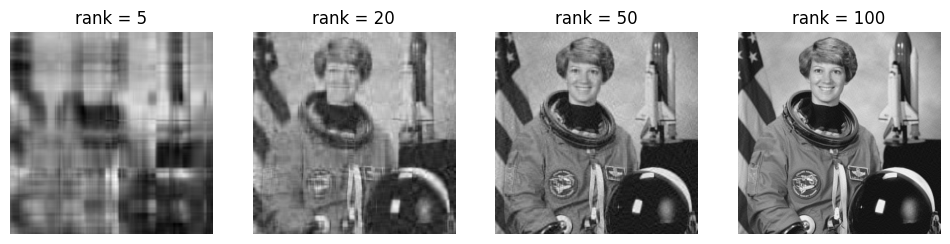

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

# Load image
img = rgb2gray(data.astronaut())

print(img.shape)

# SVD
U, S, Vt = np.linalg.svd(img, full_matrices=False)

def reconstruct(k):
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

ks = [5, 20, 50, 100]
fig, axes = plt.subplots(1, len(ks), figsize=(12, 3))

for ax, k in zip(axes, ks):
    ax.imshow(reconstruct(k), cmap='gray')
    ax.set_title(f"rank = {k}")
    ax.axis('off')

plt.show()


### 2. Text Compression and Latent Semantic Analysis (LSA) with SVD

**Motivation in AI:**
Word–document data live in extremely high-dimensional spaces (vocabulary size).
SVD uncovers latent semantic directions, explaining synonymy, topic structure, and why low-rank embeddings work in NLP.

This is the linear-algebraic ancestor of word embeddings and transformer representations.

**Mathematical Setup**

Let $X\in\mathbb{R}^{n\times d}$ be a document–term matrix, where
- rows = documents
- columns = words
- $X_{ij}$ if the frequency of TF-IDF weight of word $j$ in document $i$.

Compute
$$
X=U\Sigma V^\top
$$

- Columns of $V$: latent semantic directions (topics)
- Truncation to rank $k$: semantic compression

**Exercise:** Latent Semantic Compression with SVD

**Tasks:**
1. Build a document–term matrix from a small corpus.

2. Apply SVD.

3. Truncate to rank $k$.

4. Compare semantic similarity before and after compression.

**Interpretation**

- SVD groups synonyms and related concepts even if words never co-occur exactly.
- Rank-$k$ truncation removes noise and rare-word effects.
- Documents are embedded into a low-dimensional semantic space.

In [14]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Toy corpus
documents = [
    "machine learning improves models",
    "deep learning improves neural networks",
    "neural networks learn representations",
    "support vector machines are models",
    "probability theory and statistics"
]

# Document–term matrix
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents).toarray()

# SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Low-rank approximation
k = 4
X_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k]

# Compare similarities
sim_original = cosine_similarity(X)
sim_compressed = cosine_similarity(X_k)

print("Original similarity matrix:\n", np.round(sim_original, 2))
print("\nCompressed similarity matrix:\n", np.round(sim_compressed, 2))


Original similarity matrix:
 [[1.   0.45 0.   0.22 0.  ]
 [0.45 1.   0.45 0.   0.  ]
 [0.   0.45 1.   0.   0.  ]
 [0.22 0.   0.   1.   0.  ]
 [0.   0.   0.   0.   1.  ]]

Compressed similarity matrix:
 [[ 1.    0.65 -0.13  0.28  0.  ]
 [ 0.65  1.    0.62 -0.03  0.  ]
 [-0.13  0.62  1.    0.03 -0.  ]
 [ 0.28 -0.03  0.03  1.    0.  ]
 [ 0.    0.   -0.    0.    1.  ]]


### 3. Randomized SVD — Theory and Practice

**Motivation in AI:**
Exact SVD is $O(nd \min⁡(n,d))$ and infeasible at scale. Randomized SVD exploits concentration of measure to approximate the dominant spectral subspace with high probability. This is foundational in large-scale PCA, recommender systems, and foundation models.

**Mathematical idea:**
Approximate the column space of $A$ by
$$
Y=A\Omega,\quad \Omega\in\mathbb{R}^{d\times (k+p)}
$$
then compute SVD on a much smaller matrix.

**Exercise:**
1. Generate a low-rank + noise matrix.

2. Implement randomized SVD.

3. Compare spectral/Frobenius error to exact SVD.

In [11]:
import numpy as np

def randomized_svd(A, k, p=10):
    n, d = A.shape
    Omega = np.random.randn(d, k + p)
    Y = A @ Omega
    Q, _ = np.linalg.qr(Y)
    B = Q.T @ A
    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ Ub
    return U[:, :k], S[:k], Vt[:k]

# Test matrix
n, d, r = 500, 300, 10
U = np.random.randn(n, r)
V = np.random.randn(d, r)
A = U @ V.T + 0.01 * np.random.randn(n, d)

U_r, S_r, Vt_r = randomized_svd(A, k=10)

# Exact SVD
U_e, S_e, Vt_e = np.linalg.svd(A, full_matrices=False)

err = np.linalg.norm(A - U_r @ np.diag(S_r) @ Vt_r, 'fro')
print("Randomized SVD error:", err)


Randomized SVD error: 5.227318225710342


### 4. PCA vs Random Projection

(Spectral vs Non-Spectral Dimensionality Reduction)

**Motivation in AI:**
PCA is an optimal spectral method maximizing variance, while random projection is data-independent and extremely scalable. Many large ML systems rely on this tradeoff between optimality and efficiency.

**Exercise:**

1. Generate high-dimensional data.

2. Reduce dimensionality using PCA and random projection.

3. Compare how well pairwise distances are preserved.

In [3]:
import numpy as np

n, d, k = 500, 200, 20
X = np.random.randn(n, d)

# Center data
Xc = X - X.mean(axis=0)

# PCA
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
X_pca = Xc @ Vt[:k].T

# Random projection
R = np.random.randn(d, k) / np.sqrt(k)
X_rp = Xc @ R

def avg_pairwise_distance(X):
    idx = np.random.choice(len(X), 100, replace=False)
    D = np.linalg.norm(X[idx][:, None] - X[idx][None, :], axis=2)
    return D.mean()

print("Original:", avg_pairwise_distance(Xc))
print("PCA:", avg_pairwise_distance(X_pca))
print("Random Projection:", avg_pairwise_distance(X_rp))


Original: 19.766485060860553
PCA: 9.550368612332633
Random Projection: 19.633143432683152


### 5. Moore–Penrose Pseudoinverse and Implicit Bias

**Motivation in AI:**
In overparameterized linear models, gradient descent converges to the minimum-norm solution, which is exactly the pseudoinverse solution. This phenomenon is a key example of implicit regularization.

**Exercise:**

1. Solve an underdetermined linear system using the pseudoinverse.

2. Verify that the solution has minimum Euclidean norm.

3. Interpret the result in the context of overparameterized models.

In [2]:
import numpy as np

n, d = 50, 200  # underdetermined system
A = np.random.randn(n, d)
x_true = np.random.randn(d)
b = A @ x_trueimplicitimplicitimplicitimplicitimplicit

x_pinv = np.linalg.pinv(A) @ b

print("Norm of true solution:", np.linalg.norm(x_true))
print("Norm of pseudoinverse solution:", np.linalg.norm(x_pinv))
print("Residual norm:", np.linalg.norm(A @ x_pinv - b))


Norm of true solution: 14.24153920197583
Norm of pseudoinverse solution: 7.260650620791276
Residual norm: 2.2772103243749694e-13
